# 260831 PyTorch, RNN
[machine learning chapter04-1, 2]


---

## 1. Today's Goal

- 배운개념 정리 및 이해
- 실습코드 플로우 이해


---

## 2. Key Concepts

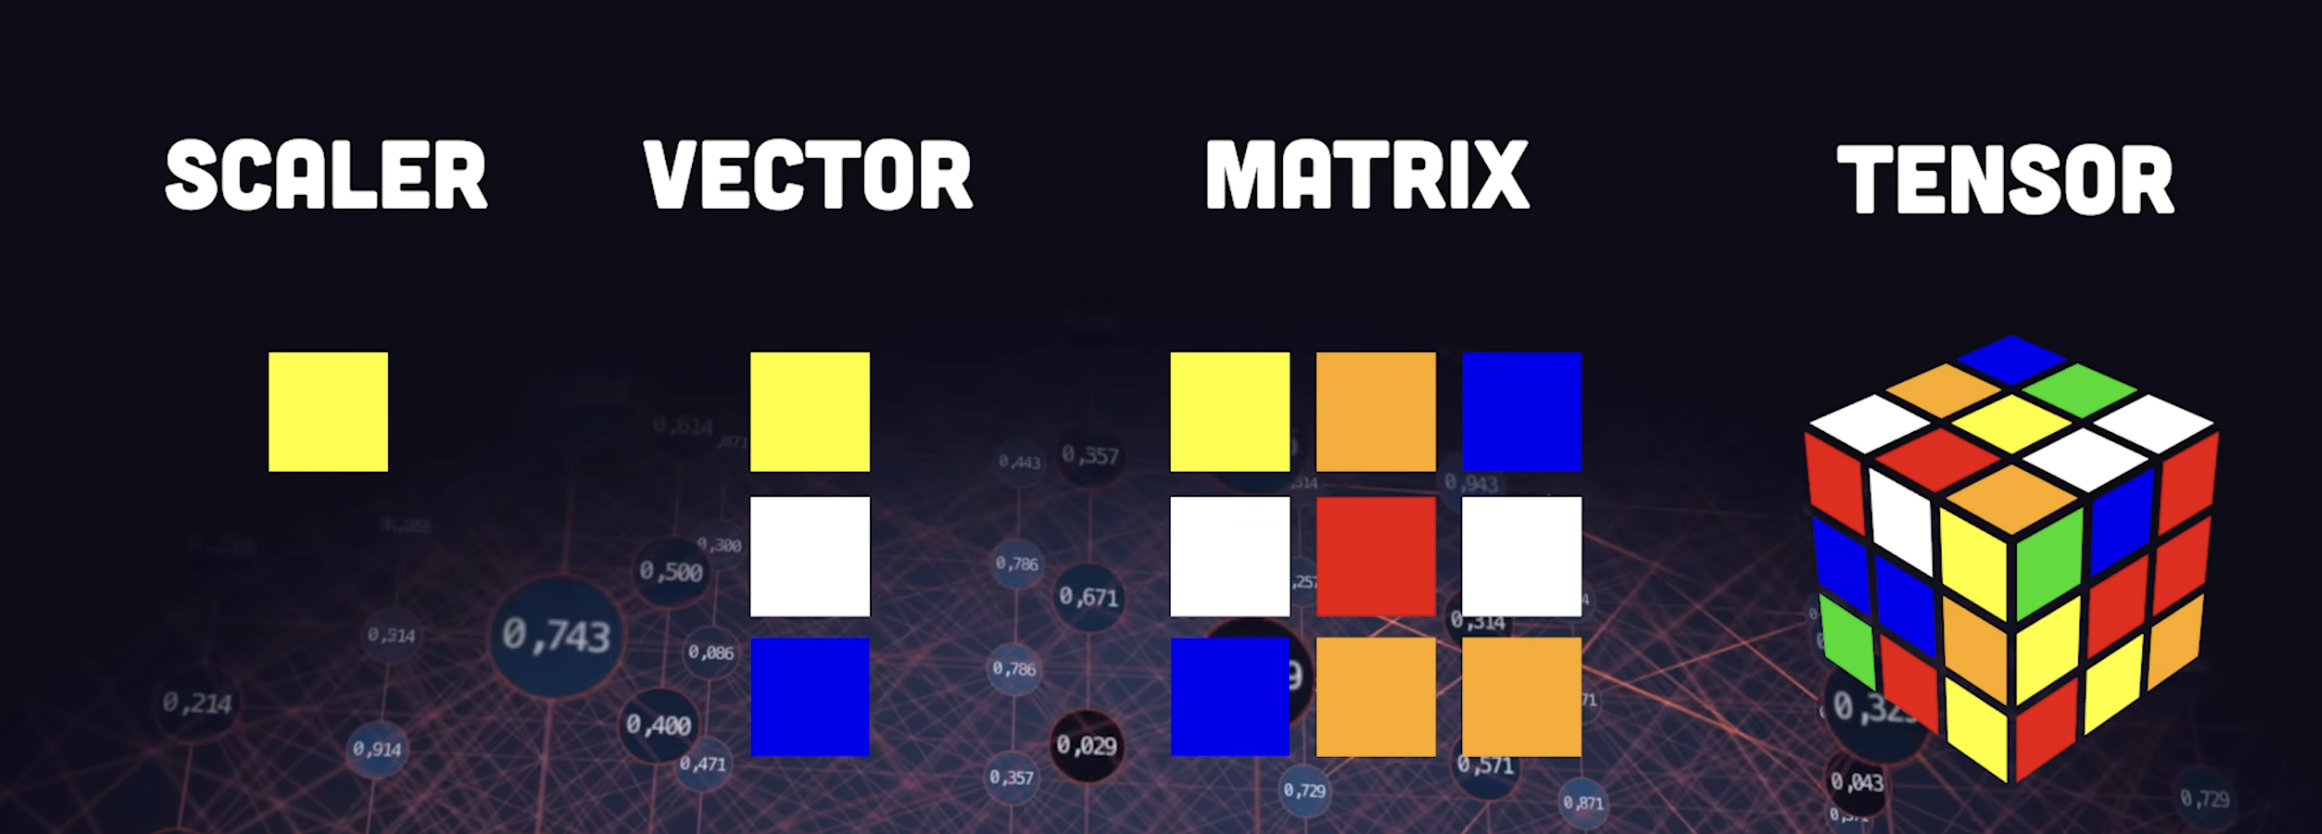

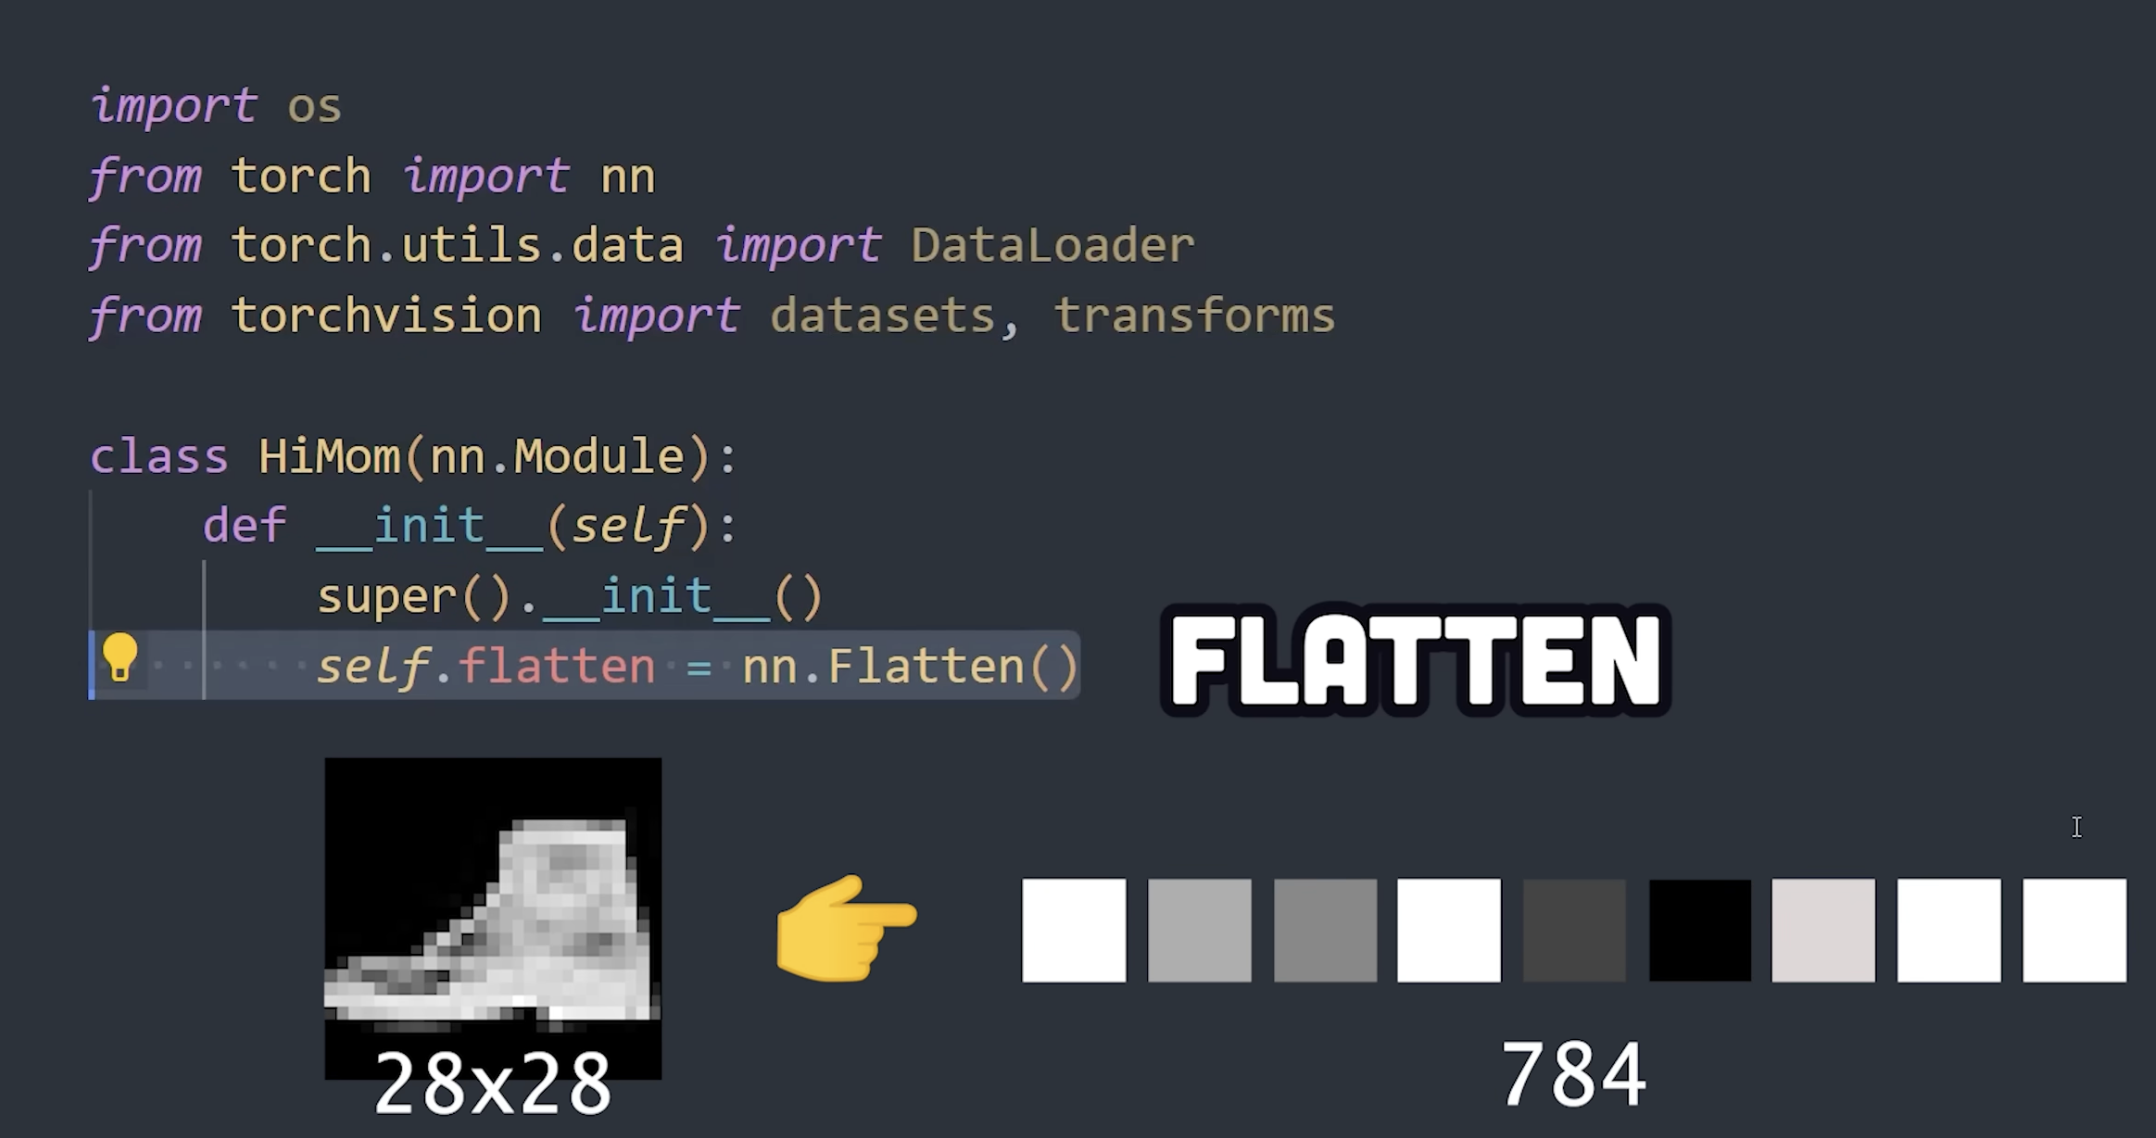

`nn.Flatten()`

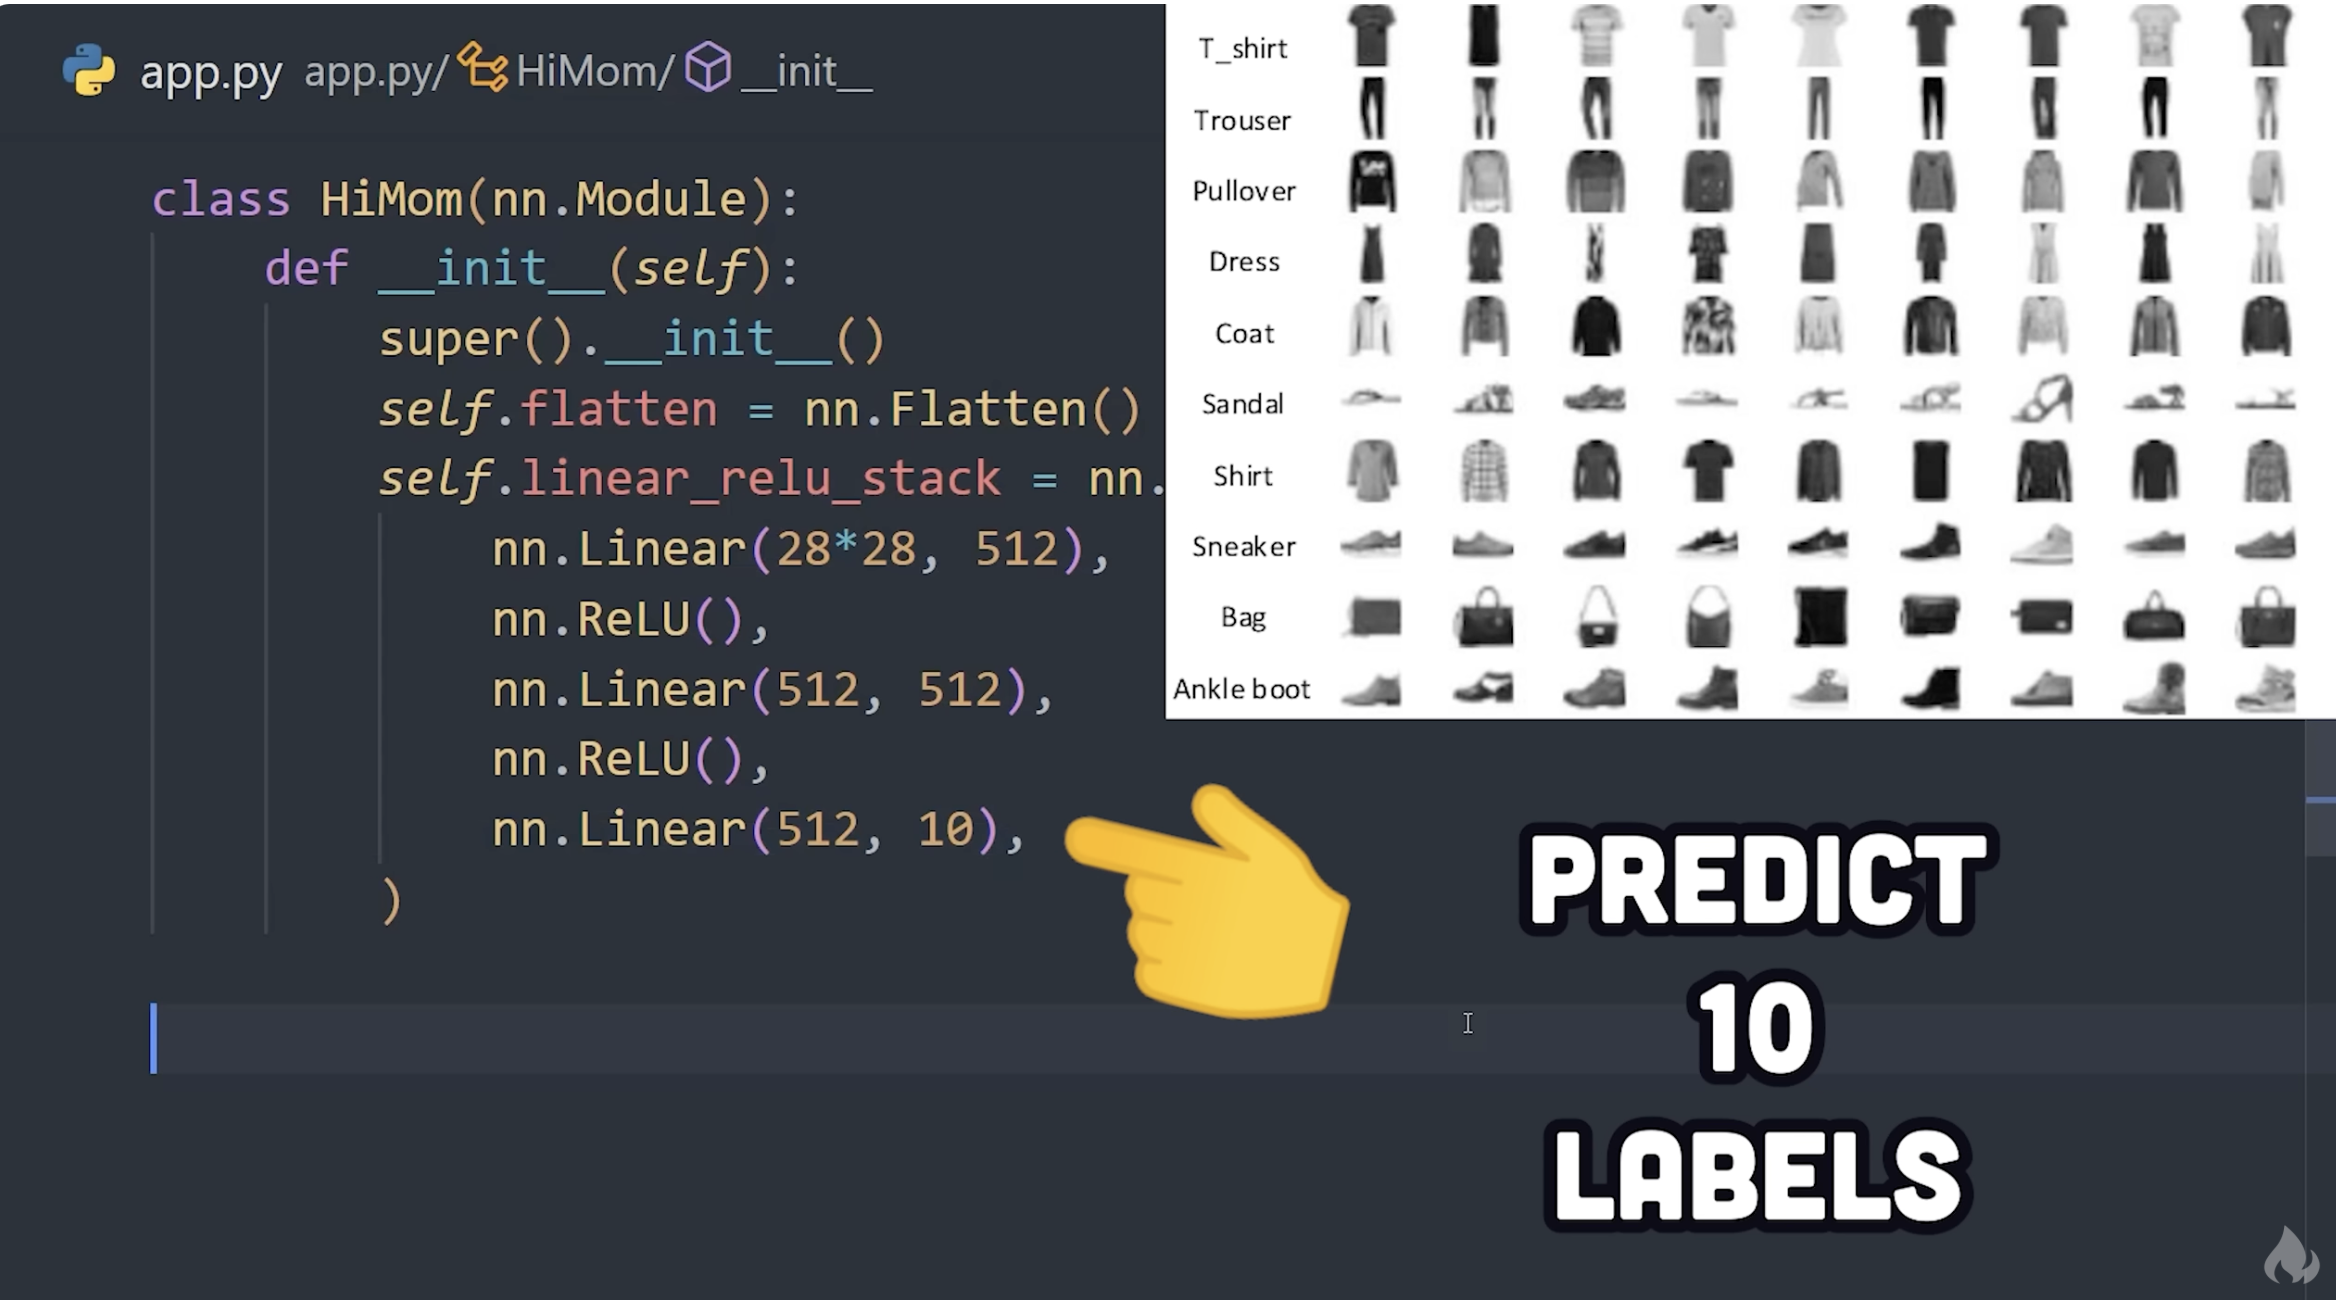

#### PyTorch
- deep learning framework
- NVIDIA's cuda --> GPA instead of CPU, enabling dynamic computation graph -> super fast computation!!
- Autograd : AI 자동학습 위해 역전파 미분 계산 자동으로 처리

#### torchvision
- 이미지, 영상 처리 
- dataset ex) MNIST, CIFAR-10, ImageNet ...
- 이미지 가공 -> AI가 학습하기 좋게 만듦


#### DNN vs. RNN 순방향 vs 순환 신경망
단층 퍼셉트론
-  z = wx + b 
-  직선 형태의 판별선
-  아무것도 거치지 않고 바로 최종 출력 점수 산출


다층 퍼셉트론
- first layer (1층): 선, 면 등 저차원 감지
- hidden layer(s) (2층): 사물의 형태, 질감 등 고차원 정보를 활성화함수를 통해 학습
- 은닉층 많을수록 
  - overfitting : 파라미터가 너무 많으면 모델이 다 외워버림
  - 기울기 소실 vanishing gradient (Sigmoid 한계): 층이 너무 깊어지면, 출력층에서 계산된 오차가 역전파 과정에서 희미해짐 -> 앞쪽 층에 있는 파라미터들이 업데이트가 제대로 안됨 -> 학습이 전혀 이루어지지 않을 수 있음 (너무 희석)
  - 은닉층 늘어날 때마다 조율해야 하는 w, b도 같이 늘어남 -> 메모리 및 시간 낭비
  --> 하이퍼파라미터 튜닝 중요 : 데이터의 복잡도에 맞게 적절한 깊이와 뉴런 수를 찾아야함



RNN recurring neural network
- 'recurring' nerual(connected with each other) network as is
- 데이터 등장 순서가 정보의 맥락을 결정하는 데이터 유형 ex) 시계열 데이터
- 선후관계적 맥락 -> 가중치 공유, 루프 연결

- cell(순환층 내부 기본 연산 유닛)
- tanh(비선형 활성화 함수, 순환층 내부): 임의의 입력값을 무조건 -1~1 사이 float 출력 범위로 정규화(bounding) -> 반복 루프를 많이 돌더라도 정보가 무한히 발산하지 않고 안정적인 제어가 가능
- RNN에서 ReLU 사용시 Exploding Gradient 발생

- RNN 단점:
  - 장기 의존성 문제 : 은닉 상태가 여러 시점 거침 -> 기울기 소실(과거정보유실) , 문장 길수록 초반단어 영향력 약해짐
- LSTM(Long Short-Term Memory): RNN 기울기 손실 문제 극복 방안, cell state와 gate 구조를 도입: 시점 길어져도 중요정보 보존+불필요정보 삭제

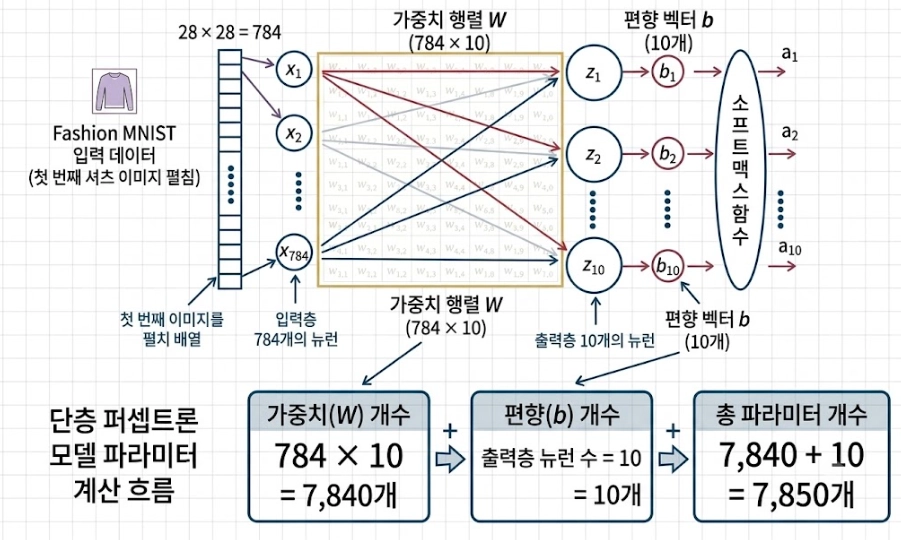

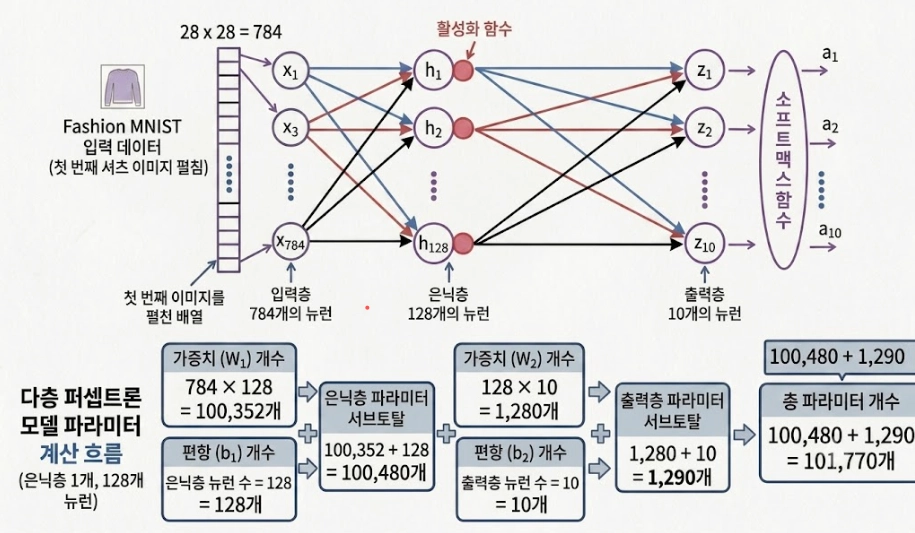

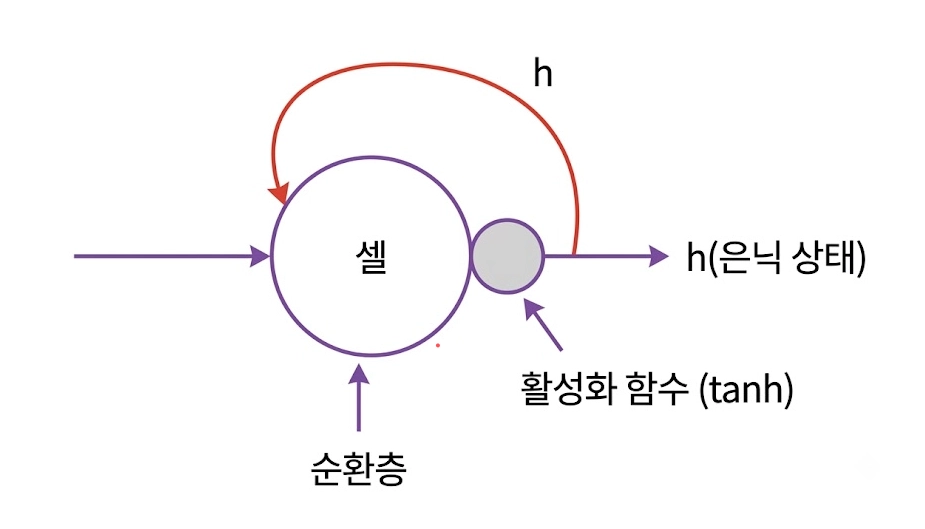

기본 셀 아키텍처

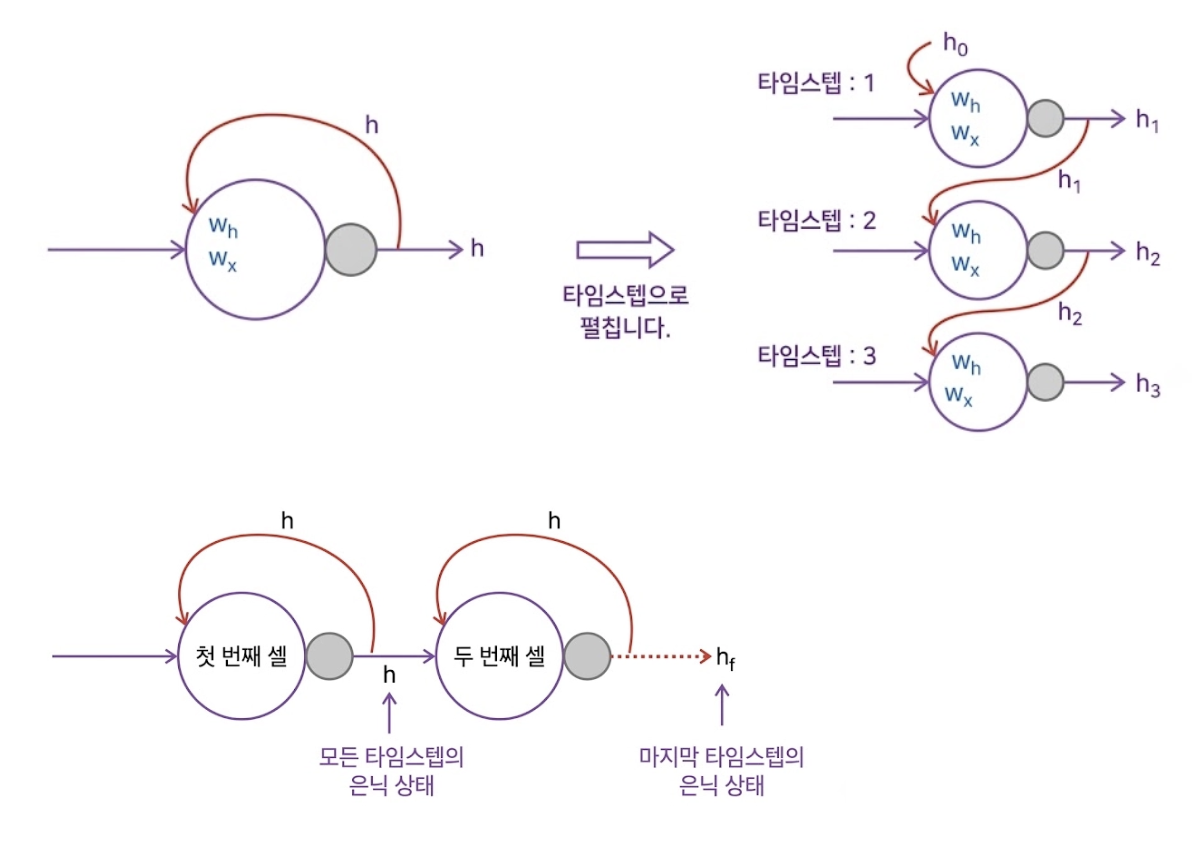

타임 스텝
- 마지막 타입스텝 은닉 상태(최종시점) : 텍스트 전체의 맥락이 하나로 압축됨 h1 ~ hf, 고정된 1차원 형태인 벡터 구조로 추출됨 -> flatten 사용 필요 x, 1차원 은닉 벡터는 softmax를 통해 바로 손실 값 예측 연산으로 이어짐 -> 파이프라인 연산 효율성 향상

h
- 최종 은닉: '맥락'을 담음 => 1차원 Context Vector
  - 책 1권을 메모장 1장에 기록한 것과 같아 '병목현상' 발생 가능
  - '메모리'
  - 학습 효율성 떨어질 수 있음 (순서가 있기 때문에)


#### Neural Learning 
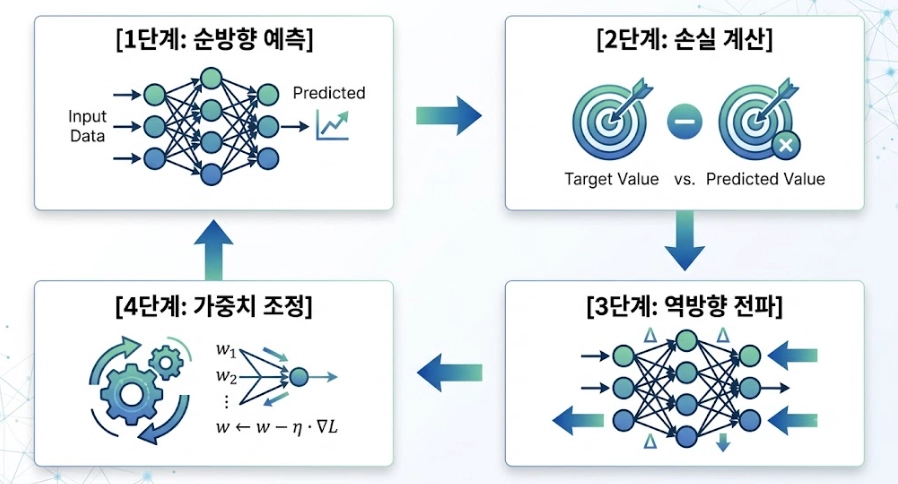

1. forward pass = 순방향 예측 -> 최종 예측값 산출
2. loss calculation = 손실 계산 -> loss = y - yhat
3. backpropagation = 역방향 오차 전파 : 출력층 오차 --> 입력층 방향으로 전파 --> 미분의 연쇄 법칙(chain rule) --> 각 가중치가 오차에 미친 영향도 기울기 계산
4. optimizer = 가중치 조정 : 3에서 계산된 기울기 바탕으로 오차 최소화 방향으로 가중치 업데이트

#### Optimizer
- 역전파: 편미분 값(Gradient) 계산에만 관여
- 옵티마이저는 역전파가 준 편미분 값을 받고, 편미분 값 앞에 학습률을 곱해주는 주체
- 종류: 
  - SGD 확률적 경사하강법
  - Momentum
  - RMSprop
  - Adam : momentum + RMSprop 장점 합침 -> 기본 옵티마이저로 사용

#### ReLu
- 은닉층 활성화 함수 = 비선형성 특성 부여 
- 출력층 활성화 함수 = logits -> softmax/Sigmoid
- 기울기 손실 문제 해결 방안 - ReLu
- 입력 신호 음수 = 0 반환
- 입력 신호 양수 = 입력값 그대로 반환, 기울기 1.0 고정 -> 양수 구간 층이 많아도 기울기 보존되어 초기 은닉층 가중치까지 오차가 온전히 전달, 안정적인 학습 가능

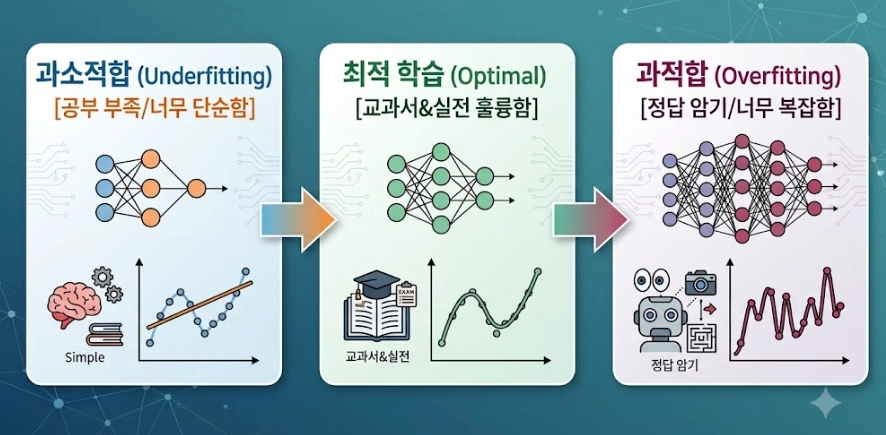

- otpimal graph -> 정답을 약간 벗어남

underfitting
- 해결: 은닉층 추가 or 모델 용량 늘리기

overfitting
- train data 손실 낮음, valiation data 손실 반등
- 해결: 드롭아웃 적용 -> 학습 시 설정된 비율만큼 뉴런 무작위 비활성화
      - 조기종료 구현 --> 손실 줄어들지 않고 다시 증가하는 시점 포착하여 학습 강제 종료
  
#### dropout
- 모델 과적합 방지 규제 기법
- 학습시, 테스트 시 다르게 동작
  - 학습 시: 은닉층 뉴런을 설정값에 따라(0.2~0.5) 무작위로 출력값을 0으로 만들어 끄고 학습 진행 -> 배치 바뀔 때마다 뉴런 조합 달라짐
  - 추론 시: 모든 뉴런 온전히 다 사용 by `model.eval()` 호출하여 dropout 비활성화
- 효과:
  - co-adoptation 방지: 강하게 학습을 주도하는 특정 뉴런에 나머지 뉴런들이 묻어가는 현상 -> 뉴런을 강재로 재워서 독자적으로 나머지 뉴런이 데이터 특징을 찾도록 훈련시킴
  - ensemble 효과: 뉴런들이 매 배치마다 무작위로 꺼짐 -> 매 순간 다른 형태의 서브네트워크를 학습 -> 테스트시 서브네트워크들이 협력하여 하나의 결과를 냄

#### one-hot encoding 단점

- sparse matrix : 희소 행렬 -> 원핫 인코딩에서 대부분의 원소과 0이고 하나의 인덱스만 1을 갖는 고차원 행렬 -> 메모리 낭비
- curse of dimensionality: 단어 사전 클수록 데이터 차원이 기하급수적으로 증가
- 의미 표현 불가: 단어간 독립성을 전제하여 단어간 유사성 파악 불가

#### embedding
- 단어의 의미적 특징을 저차원 밀집 벡터로 압축하고 float으로 채워 표현 -> 단어간의 '거리'를 나타냄
- 가중치 최적화 -> 의미 학습 메커니즘
- 입력 데이터들은 임베딩을 통과해서 셀로 들어가는 것으로 이해

---

## 3. Practice 실습 코드

In [ ]:
import torch
from torchvision import datasets
from torchvision.transforms import ToTensor 
from torch.utils.data import DataLoader, random_split

# 사용 가능한 자원 체크
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)
print(device)

# 데이터 불러오기 - raw_train_data(60,000) -> train_data(50,000), val_data(10,000). DataSet 자체를 나눠줌
raw_train_data = datasets.FashionMNIST( 
    root="data", train=True, download=True, transform=ToTensor() # train data 60000 images
) 
test_data = datasets.FashionMNIST(
    root="data", train=False, download=True, transform=ToTensor() # test data 10000 images
)

# 검증 데이터셋 분리 train/validation
train_size = 50000
val_size = 10000

train_data, val_data = random_split( # raw_train_data에서 train_data와 val_data를 지정해서 5:1씩 랜덤하게 섞어준다
    raw_train_data, [train_size, val_size], generator=torch.Generator().manual_seed(42)
)

print("훈련 세트:", len(train_data)) # 분리된 셋 확인
print("검증 세트:", len(val_data))
print("테스트 세트:", len(test_data))

# feeding the data to the model by batch_size
train_loader = DataLoader(train_data, batch_size=32, shuffle=True) 
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

mps
훈련 세트: 50000
검증 세트: 10000
테스트 세트: 10000


`root='data'`
- 'data' 폴더 만들기

`train=True`
- 훈련데이터 세트 가져오기 (훈련일때만 True)

`transform=ToTensor()`
- 이미지 데이터를 파이토치가 계산할 수 있는 텐서형태로 변환
- 0 ~ 255 범위의 픽셀 정수값을 255로 알아서 나누어 0.0 ~ 1.0 사이 float scaling

`random_split(dataset, lengths, generator=torch.Generator().manual_seed(42))`
- non-overlapping new dataset randomly split by given lengths
- dataset: dataset to be split
- lengths(sequence) : lengths or fractions of splits to be produced

`DataLoader(data, batch_size=64, shuffle=True)`
- iterator
- minibatches SGD: 조금씩 학습해야 안정적, 메모리 부족 문제 해결
- shuffle: 매 epoch마다 데이터 순서 섞어주기(train에서 필요)
- speed up by multiprocessing
- batch_size=32: split the dataset by 32 at each epoch

In [2]:
# chapter04-1 문제 1
# uv add torch torchvision
import torch.nn as nn
import torch.optim as optim

class AdvancedFashionClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten() # 평탄화  
        self.hidden_layer = nn.Linear(784, 64) # 은닉 = input 784 -> neuron 64 
        self.relu = nn.ReLU() 
        self.output_layer = nn.Linear(64, 10) #최종 출력층 64 -> 10
        self.dropout = nn.Dropout(p=0.2)

    def forward(self, x):
        out = self.flatten(x) # 입력층 처리 28*28 -> 784
        out = self.hidden_layer(out) # 은닉층 784 -> 64
        out = self.relu(out) # 활성화 함수 통과(선형적 -> 비선형적)
        out = self.dropout(out) # 훈련시에만 필요, 과대적합 방지
        out = self.output_layer(out) # 출력층 64 -> 10
        return out

model = AdvancedFashionClassifier()
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01) # optimizer SGD 사용, learning rate = 0.01

total_params= sum(p.numel() for p in model.parameters() if p.requires_grad) 
print(f"학습 가능한 모델 파라미터 총 개수: {total_params:,}개")


학습 가능한 모델 파라미터 총 개수: 50,890개


In [8]:
# chapter04-1 문제 2

# 데이터 로더 생성 구문에서 배치 크기(batch_size) 파라미터를 64로 변경하고, 데이터가 무작위로 섞이도록 셔플(shuffle) 옵션을 True로 지정
train_loader = DataLoader(train_data, batch_size=64, shuffle=True) 
val_loader = DataLoader(val_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=True)

# 전체 훈련 데이터셋에 대해 순방향 예측, 손실 계산, 역방향 오차 전파, 가중치 업데이트의 4단계 과정을 수행하는 for 루프 기반의 학습 루프를 작성
epochs = 10
patience = 5
patience_count = 0
best_val_loss = float('inf')

train_losses = []
val_losses = []


print("\n모델 학습 및 검증을 시작합니다")
for epoch in range(epochs):
    running_loss = 0.0
    model.train()

    for images, labels in train_loader:
        images = images.to(device) #
        labels = labels.to(device)

        optimizer.zero_grad()

        # 순방향 예측
        outputs=model(images)

        # 손실 계산
        loss = criterion(outputs, labels)

        # 오차 역전파 
        loss.backward()

        # 가중치 업데이트
        optimizer.step()
        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    epoch_val_loss = val_loss / len(val_loader)
    val_losses.append(epoch_val_loss)

    print(f"Epoch [{epoch+1}/{epochs}] | 훈련손실: {epoch_loss:.4f}| 검증손실: {epoch_val_loss:.4f}")        

    # 5에포크 동안 매 에포크가 종료될 때마다 계산된 평균 훈련 손실값(Loss)이 터미널 창에 출력되도록 작성
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_count = 0
        torch.save(model.state_dict(), "best_fashion_model.pth")
        print(f"최저 검증 손실: {best_val_loss:.4f}")
    else:
        patience_count += 1
        print(f"조기 종료 대기 카운트: {patience_count}/{patience}")

        # patience 한계 초과시 학습 강제 중단
        if patience_count >= patience:
            print("\n[Early Stopping 활성화] {epoch+1} 에포크에서 학습을 조기 종료합니다.")

            break


모델 학습 및 검증을 시작합니다
Epoch [1/10] | 훈련손실: 0.3752| 검증손실: 0.3778
최저 검증 손실: 0.3778
Epoch [2/10] | 훈련손실: 0.3762| 검증손실: 0.3751
최저 검증 손실: 0.3751
Epoch [3/10] | 훈련손실: 0.3720| 검증손실: 0.3821
조기 종료 대기 카운트: 1/5
Epoch [4/10] | 훈련손실: 0.3706| 검증손실: 0.3680
최저 검증 손실: 0.3680
Epoch [5/10] | 훈련손실: 0.3686| 검증손실: 0.3662
최저 검증 손실: 0.3662
Epoch [6/10] | 훈련손실: 0.3669| 검증손실: 0.3719
조기 종료 대기 카운트: 1/5
Epoch [7/10] | 훈련손실: 0.3652| 검증손실: 0.3636
최저 검증 손실: 0.3636
Epoch [8/10] | 훈련손실: 0.3644| 검증손실: 0.3691
조기 종료 대기 카운트: 1/5
Epoch [9/10] | 훈련손실: 0.3621| 검증손실: 0.3638
조기 종료 대기 카운트: 2/5
Epoch [10/10] | 훈련손실: 0.3602| 검증손실: 0.3628
최저 검증 손실: 0.3628


--- 
## 4. Daily Quest

[헷갈린 문제]
> 훈련 데이터의 손실(Loss)은 계속 낮아지지만, 검증 데이터의 손실이 더 이상 줄지 않고 다시 상승하는 현상을 무엇이라고 하나요?

과적합 overfitting : 훈련데이터에서 손실 낮음(오류 낮), 검증데이터에서 손실 반등(오류 증가)

> Momentum의 관성 개념과 RMSprop의 파라미터별 적응적 학습률 조절 방식을 결합한 하이브리드 옵티마이저로, 대부분의 딥러닝 태스크에서 기본값으로 널리 쓰이는 것은? : Adam
- hyperparameter 종류
- SGD: 단순 경사하강법
- Dropout: 규제 기법
- CrossEntropyLoss: 손실 함수


> RNN의 '순환층'에서 ReLU 대신 tanh 활성화 함수를 주로 사용하는 이유?
-> 

--- 
## 5. Reflection

- 오늘은 정말 숨이 가쁘게 몰아친 수업이었다;
- 머신러닝 초반에 패드로 직접 구조를 그리며 이해하는게 도움이 되었는데 다시 그 방법으로 복습해야겠다. 머리속에 너무 많은 개념이 들어와서 이어지지가 않는 느낌...?
- formula 같이 세세한 부분보다는 큰 그림을 그려 이해하고 넘어가는게 훨씬 더 도움이 된다